# 멀티 에이전트 감독자 (Multi-Agent Supervisor)

이 튜토리얼에서는 **LangGraph**를 활용하여 다중 에이전트 시스템을 구축하고, 에이전트 간 작업을 효율적으로 조정하고 감독자(Supervisor)를 통해 관리하는 방법을 살펴봅니다. 여러 에이전트를 동시에 다루며, 각 에이전트가 자신의 역할을 수행하도록 관리하고, 작업 완료 시 이를 적절히 처리하는 과정을 다룹니다.

> **참고 문서**: [LangGraph Multi-Agent Supervisor](https://docs.langchain.com/oss/python/langchain/multi-agent/subagents-personal-assistant)

---

## 개요

이전 튜토리얼에서는 초기 연구자(Researcher) 에이전트의 출력에 따라 메시지를 자동으로 라우팅하는 방식을 보여주었습니다. 그러나 에이전트가 여러 개로 늘어나고, 이들을 조정해야 할 경우, 단순한 분기 로직만으로는 한계가 있습니다.

여기서는 LLM을 활용한 Supervisor를 통해 에이전트들을 관리하고, 각 에이전트 노드의 결과를 바탕으로 팀 전체를 조율하는 방법을 소개합니다.

**중점 사항:**

- Supervisor는 다양한 전문 에이전트를 한 데 모아, 하나의 팀(team)으로 운영하는 역할을 합니다.
- Supervisor 에이전트는 팀의 진행 상황을 관찰하고, 각 단계별로 적절한 에이전트를 호출하거나 작업을 종료하는 등의 로직을 수행합니다.

---

## 이 튜토리얼에서 다룰 내용

- **설정(Setup)**: 필요한 패키지 설치 및 API 키 설정 방법
- **도구 생성(Tool Creation)**: 웹 검색 및 플롯(plot) 생성 등, 에이전트가 사용할 도구 정의
- **에이전트 감독자 생성(Creating the Supervisor)**: 작업자(Worker) 노드의 선택 및 작업 완료 시 처리 로직을 담은 Supervisor 생성
- **그래프 구성(Constructing the Graph)**: 상태(State) 및 작업자(Worker) 노드를 정의하여 전체 그래프 구성
- **팀 호출(Invoking the Team)**: 그래프를 호출하여 실제로 다중 에이전트 시스템이 어떻게 작동하는지 확인

## 환경 설정

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다.
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-Tutorial


## 모델 설정

본 튜토리얼에 사용할 모델을 설정합니다. LangChain v1의 `init_chat_model` 함수를 사용하여 모델을 초기화합니다.

아래 코드는 Claude Sonnet 4.5 모델을 사용하도록 설정합니다.

In [3]:
from langchain.chat_models import init_chat_model

# 사용할 모델 이름 설정 (OpenAI 키를 사용하는 경우 gpt-5.2, gpt-4.1-mini 등으로 변경하세요.)
MODEL_NAME = "claude-sonnet-4-5"

# 모델 초기화
model = init_chat_model(MODEL_NAME)
print(f"사용 모델: {MODEL_NAME}")

사용 모델: claude-sonnet-4-5


## 상태 정의

멀티 에이전트 시스템에서 활용할 상태(State)를 정의합니다. `messages`는 에이전트 간 공유하는 메시지 목록이며, `next`는 다음으로 라우팅할 에이전트를 나타냅니다.

아래 코드는 에이전트 상태 스키마를 정의합니다.

In [4]:
import operator
from typing import Sequence, Annotated
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage


# 상태 정의
class AgentState(TypedDict):
    # 에이전트 간 공유하는 메시지 목록
    messages: Annotated[Sequence[BaseMessage], operator.add]
    # 다음으로 라우팅할 에이전트
    next: str

## 에이전트 생성

### 도구(Tool) 생성

이 예제에서는 검색 엔진을 사용하여 웹 조사를 수행하는 에이전트와 플롯을 생성하는 에이전트를 만듭니다. 

- **Research Agent**: `TavilySearch` 도구를 사용하여 웹 조사를 수행합니다.
- **Coder Agent**: `@tool` 데코레이터로 정의한 `python_repl_tool`을 사용하여 Python 코드를 실행합니다.

아래 코드는 두 도구를 정의합니다.

In [5]:
import io
import sys
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool

# 최대 5개의 검색 결과를 반환하는 Tavily 검색 도구 초기화
tavily_tool = TavilySearch(max_results=5)


def run_python_code(code: str) -> str:
    """Python 코드를 실행하고 stdout 출력을 반환합니다."""
    old_stdout = sys.stdout
    sys.stdout = buffer = io.StringIO()
    try:
        exec(code, {})
    except Exception as e:
        sys.stdout = old_stdout
        return f"Error: {repr(e)}"
    sys.stdout = old_stdout
    return buffer.getvalue()

# 로컬에서 코드를 실행하는 Python REPL 도구 초기화
@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Python 코드를 실행합니다. 값의 출력을 보려면 print(...)를 사용해야 합니다."""
    try:
        # 주어진 코드를 실행하고 결과 반환
        result = run_python_code(code)
    except BaseException as e:
        return f"Failed to execute code. Error: {repr(e)}"
    return result

## Agent 노드 생성 유틸리티 구현

LangGraph를 사용하여 다중 에이전트 시스템을 구축할 때, **도우미 함수(Utility Function)**는 에이전트 노드를 생성하고 관리하는 데 중요한 역할을 합니다. 이러한 함수는 코드의 재사용성을 높이고, 에이전트 간의 상호작용을 간소화합니다.

이 섹션에서 구현할 유틸리티는 다음과 같은 역할을 수행합니다.

- **에이전트 노드 생성**: 각 에이전트의 역할에 맞는 노드를 생성하기 위한 함수 정의
- **작업 흐름 관리**: 에이전트 간의 작업 흐름을 조정하고 최적화하는 유틸리티 제공
- **결과 변환**: 에이전트의 응답을 표준화된 형식으로 변환하여 다른 에이전트와 공유

`functools.partial`을 활용하면 같은 함수를 여러 에이전트에 재사용할 수 있어 코드 중복을 크게 줄일 수 있습니다.

### agent_node 함수 정의

다음은 `agent_node`라는 함수를 정의하는 예시입니다. 이 함수는 주어진 상태(state)와 에이전트를 사용하여 에이전트를 실행하고, 결과를 `AIMessage` 형식으로 변환하여 반환합니다.

이 함수를 나중에 `functools.partial`을 사용하여 특정 에이전트와 이름이 바인딩된 노드 함수로 만들 것입니다.

아래 코드는 에이전트 노드 생성 함수를 정의합니다.

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage


def agent_node(state, agent, name):
    """에이전트 노드 함수

    지정한 agent를 실행하고, 결과를 HumanMessage로 변환하여 반환합니다.
    """
    # 에이전트를 현재 상태로 호출
    agent_response = agent.invoke(state)
    return {
        "messages": [
            HumanMessage(content=agent_response["messages"][-1].content, name=name)
        ]
    }

### functools.partial의 역할

`functools.partial`은 기존 함수의 일부 인자 또는 키워드 인자를 미리 고정하여 새 함수를 생성하는 Python 내장 유틸리티입니다. 자주 사용하는 함수 호출 패턴을 간소화할 수 있습니다.

**주요 역할**

1. **미리 정의된 값으로 새 함수 생성**: 기존 함수의 일부 인자를 미리 지정해서 새 함수를 반환합니다.
2. **코드 간결화**: 자주 사용하는 함수 호출 패턴을 단순화하여 코드 중복을 줄입니다.
3. **가독성 향상**: 특정 작업에 맞춰 함수의 동작을 맞춤화해 더 직관적으로 사용 가능하게 만듭니다.

**예시 코드**

```python
research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")
```

위 코드에서 `functools.partial`은 `agent_node` 함수에 `agent=research_agent`와 `name="Researcher"`라는 값을 고정합니다. 이제 `research_node`는 `state`만 전달하면 됩니다.

```python
# 기존 방식: 매번 모든 인자 전달
agent_node(state, agent=research_agent, name="Researcher")

# partial 사용 후: state만 전달
research_node(state)
```

### Research Agent 생성

이제 `functools.partial`을 사용하여 `research_node`를 생성합니다. `create_agent`로 Research Agent를 만들고, 이를 `agent_node` 함수와 결합하여 노드 함수로 변환합니다.

아래 코드는 Research Agent와 해당 노드를 생성합니다.

In [7]:
import functools
from langchain.agents import create_agent

# Research Agent 생성: Tavily 검색 도구를 사용하는 에이전트
research_agent = create_agent(
    model, 
    tools=[tavily_tool],
    system_prompt=(
        "You can only do research. You are working with a coder colleague."
    ),
)

# research_node 생성: agent_node 함수에 agent와 name을 바인딩
research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")

### Research Agent 테스트

생성된 `research_node`가 정상적으로 동작하는지 확인합니다. 테스트 메시지를 전달하여 에이전트가 응답을 생성하는지 확인할 수 있습니다.

아래 코드는 Research Agent 노드를 테스트합니다.

In [8]:
# Research Agent 테스트: 간단한 검색 메시지로 동작 확인
result = research_node(
    {
        "messages": [
            HumanMessage(content="테디노트에 대해서 조사 좀 해주세요.")
        ]
    }
)

# 에이전트 응답 내용 출력
print(result["messages"][-1].content)

테디노트에 대해 조사한 결과를 정리해드리겠습니다:

## 📌 테디노트 개요

**테디노트**는 **이경록(Teddy Lee)**님이 운영하는 데이터 분석 및 AI 관련 교육 브랜드입니다.

### 주요 활동 분야
- 📺 **YouTube 채널**: 데이터 분석, 머신러닝, 딥러닝, LLM(대규모 언어 모델)에 대한 콘텐츠 제공
- 📝 **블로그**: 테디노트 기술 블로그 운영 (teddylee777.github.io)
- 📚 **교육 콘텐츠**: 위키독스(Wikidocs)에서 무료 전자책 제공

### 주요 역할 및 타이틀
- **LangChain Ambassador** (랭체인 공식 앰버서더)
- **구글 TensorFlow 개발자 자격증** 대한민국 2호 취득
- YouTuber 및 AI Contents Creator

---

## 📖 저서 및 출판물

### 출판 도서
1. **"파이썬 딥러닝 텐서플로"** (정보문화사, 2021년)

### 위키독스 무료 전자책
1. **"랭체인LangChain 노트 - LangChain 한국어 튜토리얼🇰🇷"**
2. **"한 권으로 끝내는 판다스 노트"**
3. **"한 권으로 끝내는 파이썬 노트"**
4. **"한 권으로 끝내는 머신러닝 노트"**
5. **"테디노트의 RAG 비법노트: 기본편"** (2025년 5월)
6. **"테디노트의 RAG 비법노트: 심화편"** (2025년 6월)
7. **"MCP 가이드: LangChain 기반 구축과 Cursor AI 연동"**

---

## 🎓 강의 경력 (주요)

### 기업 강의
- SK그룹, SK텔레콤, GS칼텍스, S-Oil
- 삼성SDS, CJ올리브네트웍스
- DB 인재개발원, KT AI 교육센터

### 교육기관
- 서울대학교 평생교육원 (PyTorch 딥러닝, TensorFlow 개발자 과정)
- 고려대학교 기술경영대학원, 인공지능융합대학원
- 한양대학교, 금오공과대학교, 인천대학교 등

### 온라인 플랫폼
- **패스트캠퍼스**: 파이썬 데이터분석, 

## Supervisor Agent 생성

Supervisor는 여러 에이전트를 관리하고, 현재 상태를 기반으로 다음에 실행할 에이전트를 결정하는 역할을 합니다. 이 섹션에서는 Supervisor Agent를 생성합니다.

Supervisor의 핵심 역할은 다음과 같습니다.

- **작업 분배**: 사용자 요청을 분석하여 적합한 에이전트에게 작업을 할당합니다.
- **진행 상황 모니터링**: 각 에이전트의 결과를 확인하고 다음 단계를 결정합니다.
- **종료 판단**: 모든 작업이 완료되면 `FINISH`를 반환하여 워크플로우를 종료합니다.

아래 코드는 Supervisor가 반환할 응답 모델과 팀 멤버를 정의합니다.

In [9]:
from pydantic import BaseModel
from typing import Literal

# 팀 멤버 에이전트 목록 정의
members = ["Researcher", "Coder"]

# 다음 작업자 선택 옵션: FINISH + 멤버 목록
options_for_next = ["FINISH"] + members


class RouteResponse(BaseModel):
    """Supervisor의 라우팅 응답 모델

    다음으로 실행할 에이전트를 선택하거나 FINISH를 반환합니다.
    """
    next: Literal[*options_for_next]

In [10]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder


# 시스템 프롬프트: 감독자 역할 정의 및 각 에이전트의 역할 설명 포함
system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    " following workers: {members}."
    " Researcher: searches the web for information and returns raw data."
    " Coder: writes and executes Python code for data analysis and visualization."
    " Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status."
    " Do NOT call the same worker twice in a row unless their previous attempt failed."
    " Once the Researcher has provided data, pass it to the Coder for analysis or visualization."
    " When finished, respond with FINISH."
)

# ChatPromptTemplate 생성: 시스템 프롬프트 → 메시지 → 라우팅 지시 순서로 구성
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        MessagesPlaceholder(variable_name="messages"),
        (
            "human",
            "Given the conversation above, who should act next? "
            "Or should we FINISH? Select one of: {options}",
        ),
    ]
).partial(options=str(options_for_next), members=", ".join(members))


def supervisor_agent(state):
    """Supervisor Agent 함수

    현재 상태를 분석하여 다음으로 실행할 에이전트를 결정합니다.
    RouteResponse 형식으로 구조화된 출력을 반환합니다.
    """
    # 프롬프트와 모델을 결합하여 체인 구성
    supervisor_chain = prompt | model.with_structured_output(RouteResponse)
    # 체인 호출 및 결과 반환
    return supervisor_chain.invoke(state)

## 그래프 구성

이제 그래프를 구축할 준비가 되었습니다. 앞서 정의한 에이전트 노드와 Supervisor를 `StateGraph`에 등록하고, 엣지를 연결하여 워크플로우를 완성합니다.

그래프 구성의 핵심 요소는 다음과 같습니다.

- **노드 추가**: Research Agent, Coder Agent, Supervisor Agent를 그래프에 등록합니다.
- **엣지 연결**: 각 멤버 에이전트는 작업 완료 후 Supervisor로 돌아갑니다.
- **조건부 라우팅**: Supervisor는 다음 에이전트를 동적으로 결정합니다.

아래 코드는 Research Agent와 Coder Agent 노드를 생성합니다.

In [11]:
import functools
from langchain.agents import create_agent

# Coder Agent 시스템 프롬프트: 한글 폰트 설정 포함
code_system_prompt = """
Be sure to use the following font in your code for visualization.

##### 폰트 설정 #####
import platform

# OS 판단
current_os = platform.system()

if current_os == "Windows":
    # Windows 환경 폰트 설정
    font_path = "C:/Windows/Fonts/malgun.ttf"  # 맑은 고딕 폰트 경로
    fontprop = fm.FontProperties(fname=font_path, size=12)
    plt.rc("font", family=fontprop.get_name())
elif current_os == "Darwin":  # macOS
    # Mac 환경 폰트 설정
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux 등 기타 OS
    # 기본 한글 폰트 설정 시도
    try:
        plt.rcParams["font.family"] = "NanumGothic"
    except:
        print("한글 폰트를 찾을 수 없습니다. 시스템 기본 폰트를 사용합니다.")

##### 마이너스 폰트 깨짐 방지 #####
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 폰트 깨짐 방지

##### 주의사항 #####
# 시각화 결과는 plt.show()로 화면에 출력만 하세요.
# plt.savefig()를 사용하여 파일로 저장하지 마세요.
"""

# Coder Agent 생성: Python REPL 도구를 사용
coder_agent = create_agent(
    model,
    tools=[python_repl_tool],
    system_prompt=code_system_prompt,
)
coder_node = functools.partial(agent_node, agent=coder_agent, name="Coder")

In [12]:
from langgraph.graph import END, StateGraph, START
from langgraph.checkpoint.memory import MemorySaver

# StateGraph 생성: AgentState를 상태 스키마로 사용
workflow = StateGraph(AgentState)

# 그래프에 노드 추가
workflow.add_node("Researcher", research_node)
workflow.add_node("Coder", coder_node)
workflow.add_node("Supervisor", supervisor_agent)

# 멤버 노드 -> Supervisor 노드로 엣지 추가 (작업 완료 후 Supervisor로 복귀)
for member in members:
    workflow.add_edge(member, "Supervisor")

# 조건부 라우팅 맵 정의: 멤버 이름 -> 노드, FINISH -> END
conditional_map = {k: k for k in members}
conditional_map["FINISH"] = END


def get_next(state):
    """상태에서 다음 노드를 반환하는 함수"""
    return state["next"]


# Supervisor 노드에서 조건부 엣지 추가
workflow.add_conditional_edges("Supervisor", get_next, conditional_map)

# 시작점: START -> Supervisor
workflow.add_edge(START, "Supervisor")

# 그래프 컴파일: MemorySaver를 체크포인터로 사용
graph = workflow.compile(checkpointer=MemorySaver())

### 그래프 시각화

완성된 그래프 구조를 시각화하여 노드 간의 연결 관계를 확인합니다. `visualize_graph` 함수를 사용하면 그래프의 전체 구조를 한눈에 파악할 수 있습니다.

아래 코드는 컴파일된 그래프를 시각화합니다.

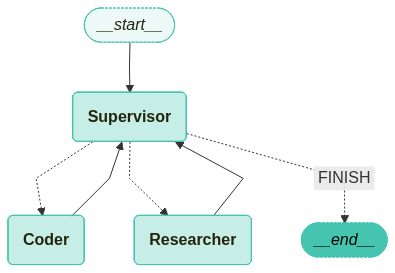

In [13]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(graph)

## 팀 호출

이제 생성된 그래프를 실행하여 Multi-Agent Supervisor 시스템의 동작을 확인합니다. 사용자 요청을 입력으로 전달하면, Supervisor가 적절한 에이전트를 선택하여 작업을 수행하고, 최종 결과를 반환합니다.

아래 예시에서는 대한민국의 1인당 GDP 추이를 시각화하는 작업을 요청합니다. Supervisor는 먼저 Researcher에게 데이터 수집을 지시하고, 이후 Coder에게 시각화를 지시합니다.

아래 코드는 그래프를 호출하여 결과를 확인합니다.


🔄 Node: Supervisor 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
next:
Researcher

🔄 Node: model in [Researcher] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================

[{'text': '2010년부터 2025년까지 대한민국의 1인당 GDP 데이터를 검색하겠습니다.', 'type': 'text'}, {'id': 'toolu_013JQYGwvzJ1PtHX7XsCGVS4', 'caller': {'type': 'direct'}, 'input': {'query': '대한민국 1인당 GDP 2010-2025 추이 데이터', 'search_depth': 'advanced'}, 'name': 'tavily_search', 'type': 'tool_use'}, {'id': 'toolu_01Fx8Td6jjiMRoYB9gcMmiMF', 'caller': {'type': 'direct'}, 'input': {'query': 'South Korea GDP per capita 2010-2025 historical data', 'search_depth': 'advanced'}, 'name': 'tavily_search', 'type': 'tool_use'}]
Tool Calls:
  tavily_search (toolu_013JQYGwvzJ1PtHX7XsCGVS4)
 Call ID: toolu_013JQYGwvzJ1PtHX7XsCGVS4
  Args:
    query: 대한민국 1인당 GDP 2010-2025 추이 데이터
    search_depth: advanced
  tavily_search (toolu_01Fx8Td6jjiMRoYB9gcMmiMF)
 Call ID: toolu_01Fx8Td6

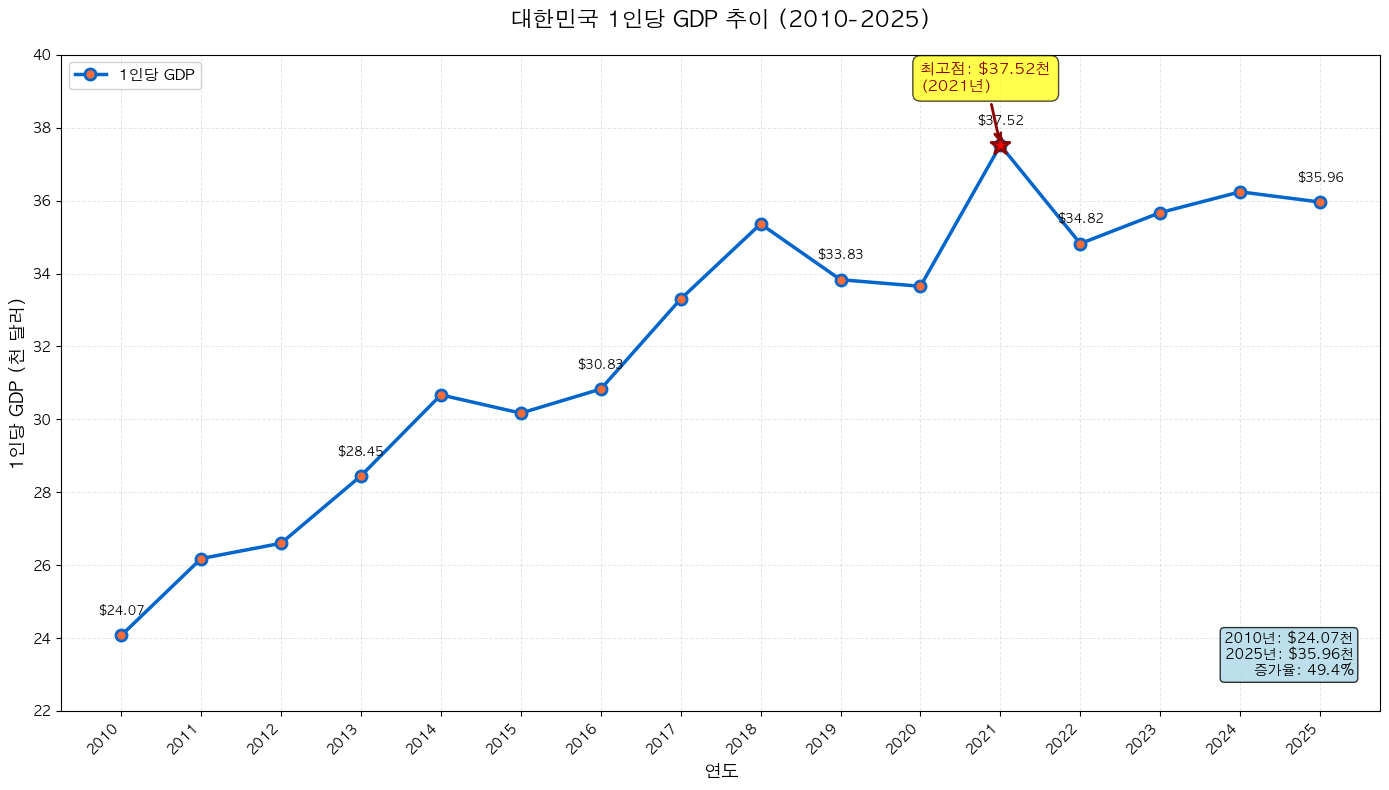


🔄 Node: tools in [Coder] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: python_repl_tool


🔄 Node: model in [Coder] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================

[{'text': '대한민국의 1인당 GDP 추이를 시각화해드리겠습니다!', 'type': 'text'}, {'id': 'toolu_01U6UdCRXJqHfVVcdtxMooVK', 'caller': {'type': 'direct'}, 'input': {'code': '\nimport matplotlib.pyplot as plt\nimport matplotlib.font_manager as fm\nimport platform\nimport numpy as np\n\n##### 폰트 설정 #####\ncurrent_os = platform.system()\n\nif current_os == "Windows":\n    font_path = "C:/Windows/Fonts/malgun.ttf"\n    fontprop = fm.FontProperties(fname=font_path, size=12)\n    plt.rc("font", family=fontprop.get_name())\nelif current_os == "Darwin":\n    plt.rcParams["font.family"] = "AppleGothic"\nelse:\n    try:\n        plt.rcParams["font.family"] = "NanumGothic"\n    exc

In [14]:
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import random_uuid, invoke_graph

# config 설정: 재귀 최대 횟수와 thread_id 지정
config = RunnableConfig(recursion_limit=20, configurable={"thread_id": random_uuid()})

# 입력 메시지 정의
inputs = {
    "messages": [
        HumanMessage(
            content="2010년 ~ 2025년까지의 대한민국의 1인당 GDP 추이를 그래프로 시각화 해주세요."
        )
    ],
}

# 그래프 실행 및 결과 출력
invoke_graph(graph, inputs, config)

## Agent-as-Tool 패턴

앞서 구현한 방식은 `StateGraph`를 직접 구성하여 Supervisor의 라우팅 로직을 명시적으로 정의하는 방법이었습니다. 이번 섹션에서는 동일한 멀티 에이전트 시스템을 **Agent-as-Tool 패턴**을 사용하여 훨씬 간결하게 구현하는 방법을 소개합니다.

Agent-as-Tool 패턴의 핵심 아이디어는 다음과 같습니다.

- **Sub-Agent를 도구(Tool)로 래핑**: 각 에이전트를 `@tool` 데코레이터로 감싸서 일반 도구처럼 사용합니다.
- **Supervisor도 에이전트로 생성**: `create_agent`로 Supervisor를 만들고, Sub-Agent 도구들을 할당합니다.
- **자동 라우팅**: Supervisor가 LLM의 도구 호출(tool calling) 기능을 활용하여 자연스럽게 적절한 Sub-Agent를 선택합니다.

이 방식은 `StateGraph`, `add_conditional_edges`, `RouteResponse` 같은 수동 배선 없이도 Supervisor 패턴을 구현할 수 있습니다.

> **참고 문서**: [LangChain Multi-Agent Supervisor](https://docs.langchain.com/oss/python/langchain/multi-agent/subagents-personal-assistant)

### Sub-Agent를 도구(Tool)로 래핑

Agent-as-Tool 패턴의 첫 번째 단계는 앞서 생성한 `research_agent`와 `coder_agent`를 `@tool` 데코레이터로 래핑하는 것입니다. 이렇게 하면 Supervisor가 각 에이전트를 일반 도구처럼 호출할 수 있게 됩니다.

각 도구의 docstring은 Supervisor가 어떤 상황에서 해당 도구를 사용할지 판단하는 데 중요한 역할을 합니다. 따라서 도구의 용도를 명확하게 기술해야 합니다.

아래 코드는 기존 에이전트를 도구로 래핑하고, Supervisor Agent를 생성합니다.

In [15]:
from langchain_core.tools import tool
from langchain.agents import create_agent
from langgraph.checkpoint.memory import MemorySaver


# Research Agent를 도구로 래핑
@tool
def research(request: str) -> str:
    """웹에서 정보를 검색하고 조사합니다. 데이터 수집, 최신 정보 확인, 사실 조사 등에 활용합니다."""
    result = research_agent.invoke(
        {"messages": [{"role": "user", "content": request}]}
    )
    return result["messages"][-1].content


# Coder Agent를 도구로 래핑
@tool
def code_execution(request: str) -> str:
    """Python 코드를 작성하고 실행합니다. 데이터 분석, 차트 생성, 시각화 등에 활용합니다."""
    result = coder_agent.invoke(
        {"messages": [{"role": "user", "content": request}]}
    )
    return result["messages"][-1].content


# Supervisor Agent 생성: Sub-Agent 도구를 사용하는 에이전트
simple_supervisor = create_agent(
    model,
    tools=[research, code_execution],
    system_prompt=(
        "You are a supervisor managing research and coding tasks. "
        "Use the research tool to search the web for information and data. "
        "Use the code_execution tool to write and execute Python code for analysis and visualization. "
        "Coordinate these tools to fulfill the user's request step by step."
    ),
    checkpointer=MemorySaver(),
)

### 그래프 시각화

Agent-as-Tool 패턴으로 생성된 Supervisor 그래프를 시각화합니다. 앞서 수동으로 구성한 그래프와 달리, `create_agent`가 내부적으로 그래프를 자동 구성합니다. Supervisor 노드 하나만 존재하고, Sub-Agent 호출은 도구 실행으로 처리되는 것을 확인할 수 있습니다.

아래 코드는 간편하게 생성된 Supervisor 그래프의 구조를 시각화합니다.

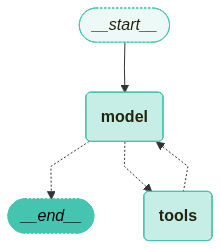

In [16]:
from langchain_teddynote.graphs import visualize_graph

# 간편한 방식의 그래프 시각화
visualize_graph(simple_supervisor)

### 팀 호출

동일한 질문을 Agent-as-Tool 패턴의 Supervisor에게 전달하여 결과를 비교합니다. Supervisor가 자동으로 `research` 도구와 `code_execution` 도구를 선택하여 작업을 수행하는 것을 확인할 수 있습니다.

앞선 StateGraph 방식과 동일한 입력을 사용하여, 두 방식의 결과를 직접 비교해 볼 수 있습니다.

아래 코드는 간편한 방식의 Supervisor 그래프를 호출하여 결과를 확인합니다.


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================

[{'text': '2010년부터 2025년까지의 대한민국 1인당 GDP 데이터를 조사한 후 그래프로 시각화해드리겠습니다.', 'type': 'text'}, {'id': 'toolu_01U1jPuR4CjFSUd5d6fUYd3L', 'caller': {'type': 'direct'}, 'input': {'request': '대한민국 1인당 GDP 2010-2025 연도별 데이터'}, 'name': 'research', 'type': 'tool_use'}]
Tool Calls:
  research (toolu_01U1jPuR4CjFSUd5d6fUYd3L)
 Call ID: toolu_01U1jPuR4CjFSUd5d6fUYd3L
  Args:
    request: 대한민국 1인당 GDP 2010-2025 연도별 데이터

🔄 Node: model in [tools] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================

[{'id': 'toolu_01LxWSahVPuj9uVZLsaCi7JV', 'caller': {'type': 'direct'}, 'input': {'query': '대한민국 한국 1인당 GDP 2010-2025 연도별 데이터', 'search_depth': 'advanced'}, 'name': 'tavily_search', 'type': 'tool_use'}, {'id': 'toolu_01XXLfXfZqACb5MvL5Pv2bDq', 'caller': {'type': 'direct'}, 'input': {

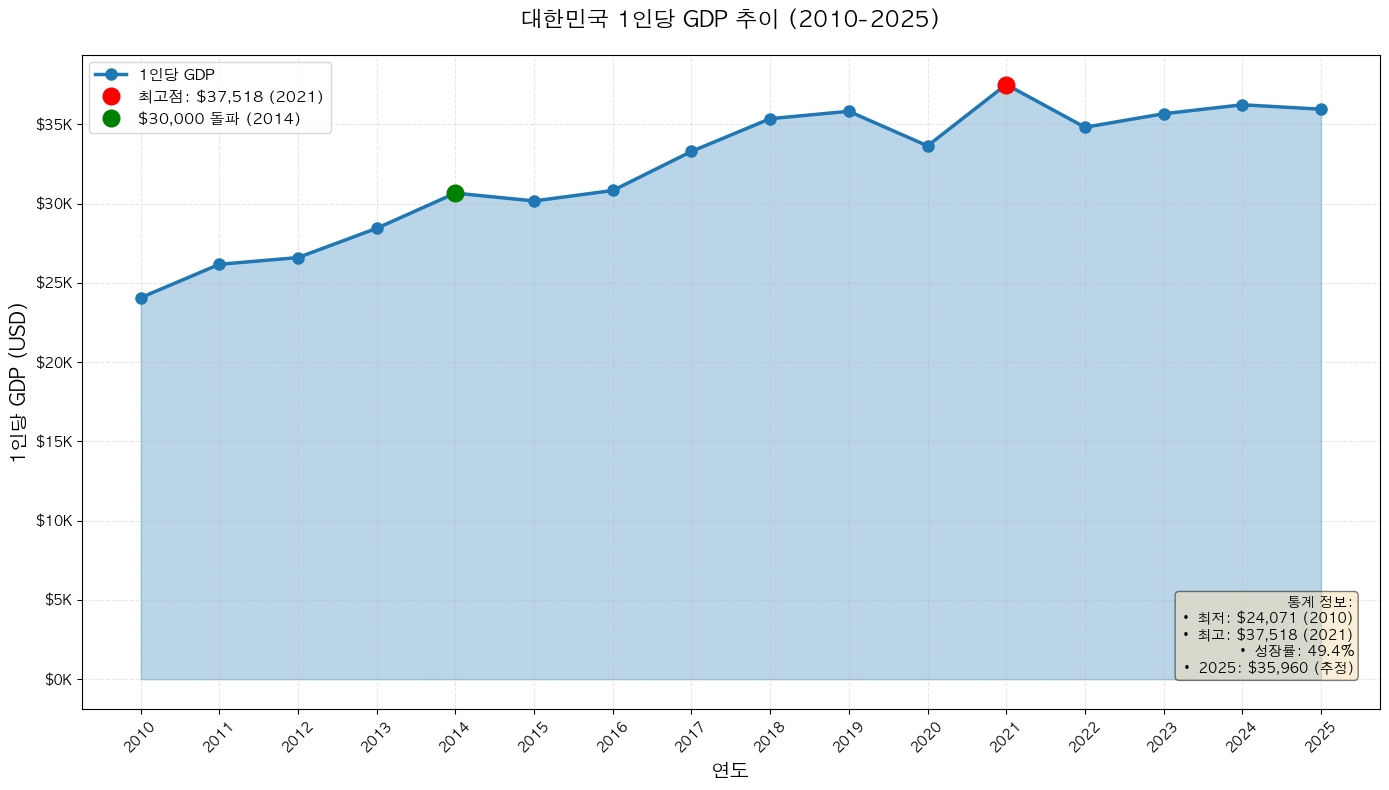


🔄 Node: tools in [tools] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: python_repl_tool


🔄 Node: model in [tools] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================

[{'text': '대한민국 1인당 GDP 데이터를 시각화하겠습니다. 제공하신 코드를 한글 폰트 설정을 적용하여 실행하겠습니다.', 'type': 'text'}, {'id': 'toolu_01SUbg7EjiGSctfuZgEq8EGd', 'caller': {'type': 'direct'}, 'input': {'code': '\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport matplotlib.font_manager as fm\nimport platform\n\n##### 폰트 설정 #####\n# OS 판단\ncurrent_os = platform.system()\n\nif current_os == "Windows":\n    # Windows 환경 폰트 설정\n    font_path = "C:/Windows/Fonts/malgun.ttf"  # 맑은 고딕 폰트 경로\n    fontprop = fm.FontProperties(fname=font_path, size=12)\n    plt.rc("font", family=fontprop.get_name())\nelif current_os == "Darwin":  # macOS\n    # Mac 환경 폰트 설정\n    plt.rcParams["

In [17]:
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import random_uuid, invoke_graph

# config 설정: 재귀 최대 횟수와 thread_id 지정
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": random_uuid()})

# 동일한 입력 메시지로 실행
inputs = {
    "messages": [
        HumanMessage(
            content="2010년 ~ 2025년까지의 대한민국의 1인당 GDP 추이를 그래프로 시각화 해주세요."
        )
    ],
}

# 간편한 방식의 그래프 실행 및 결과 출력
invoke_graph(simple_supervisor, inputs, config)

## 두 방식 비교

아래 표는 이번 튜토리얼에서 다룬 두 가지 Supervisor 구현 방식의 차이점을 정리한 것입니다.

| 비교 항목 | StateGraph 방식 | Agent-as-Tool 방식 |
|-----------|----------------|-------------------|
| **상태 정의** | `AgentState` 직접 정의 필요 | `create_agent`가 자동 생성 |
| **라우팅 로직** | `RouteResponse` + `add_conditional_edges` | LLM의 도구 호출로 자동 라우팅 |
| **그래프 구성** | `StateGraph` + 노드/엣지 수동 연결 | `create_agent` 한 줄로 완성 |
| **에이전트 추가** | 노드, 엣지, 멤버 목록 모두 수정 | `@tool` 래핑 후 도구 목록에 추가 |
| **제어 수준** | 높음 (세밀한 흐름 제어 가능) | 낮음 (LLM에 위임) |
| **적합한 경우** | 복잡한 워크플로우, 커스텀 라우팅 필요 시 | 빠른 프로토타이핑, 간단한 구조 |

**StateGraph 방식**은 그래프의 흐름을 명시적으로 제어할 수 있어 복잡한 워크플로우에 적합합니다. 반면 **Agent-as-Tool 방식**은 코드가 간결하고 에이전트 추가가 쉬워 빠르게 멀티 에이전트 시스템을 구축할 때 유용합니다. 프로젝트의 복잡도와 요구사항에 따라 적절한 방식을 선택하는 것이 좋습니다.